In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load cleaned data
oil = pd.read_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/oil_prices_cleaned.csv", index_col=0, parse_dates=True)

# Prophet requires specific column names - ds (date) and y (value)
prophet_df = oil[["Price"]].reset_index()
prophet_df.columns = ["ds", "y"]

print(prophet_df.shape)
print(prophet_df.head())
print(prophet_df.tail())

(4082, 2)
          ds          y
0 2015-01-02  56.419998
1 2015-01-03  56.419998
2 2015-01-04  56.419998
3 2015-01-05  53.110001
4 2015-01-06  51.099998
             ds          y
4077 2026-03-02  77.739998
4078 2026-03-03  81.400002
4079 2026-03-04  81.400002
4080 2026-03-05  85.410004
4081 2026-03-06  92.690002


In [3]:
# Split data into training and testing
# Train on everything up to 2024, test on 2025 onwards
train = prophet_df[prophet_df["ds"] < "2025-01-01"]
test = prophet_df[prophet_df["ds"] >= "2025-01-01"]

print(f"Training data: {len(train)} rows")
print(f"Testing data: {len(test)} rows")

# Build and train the model
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05  # controls flexibility of trend
)

model.fit(train)
print("\nModel trained successfully!")

Training data: 3652 rows
Testing data: 430 rows


16:56:20 - cmdstanpy - INFO - Chain [1] start processing
16:56:22 - cmdstanpy - INFO - Chain [1] done processing



Model trained successfully!


In [4]:
# Make future dataframe - predict through end of 2026
future = model.make_future_dataframe(periods=365)

# Generate predictions
forecast = model.predict(future)

# Show key columns
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10))

             ds       yhat  yhat_lower  yhat_upper
4007 2025-12-22  71.663434   49.029080   95.150478
4008 2025-12-23  71.660596   48.891249   94.468340
4009 2025-12-24  71.692164   48.539755   96.207617
4010 2025-12-25  71.803373   49.683486   95.615229
4011 2025-12-26  71.963459   49.417290   96.481580
4012 2025-12-27  71.993287   49.709912   96.488683
4013 2025-12-28  72.020777   49.204909   96.375193
4014 2025-12-29  71.932851   48.482434   95.792769
4015 2025-12-30  71.912971   48.514589   96.743566
4016 2025-12-31  71.930511   48.925465   95.889717


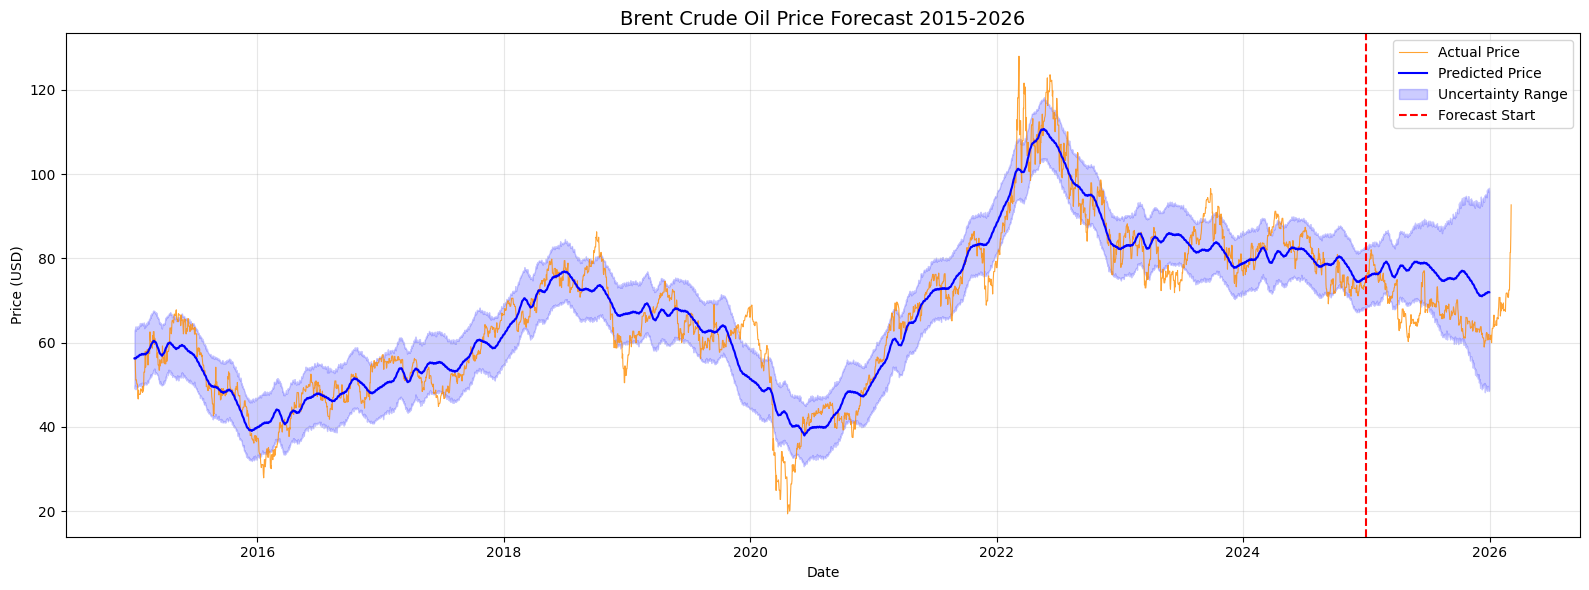

In [5]:
# Plot the forecast
fig, ax = plt.subplots(figsize=(16, 6))

# Plot actual prices
ax.plot(prophet_df["ds"], prophet_df["y"], 
        color="darkorange", linewidth=0.8, label="Actual Price", alpha=0.8)

# Plot predicted prices
ax.plot(forecast["ds"], forecast["yhat"], 
        color="blue", linewidth=1.5, label="Predicted Price")

# Plot uncertainty bands
ax.fill_between(forecast["ds"], 
                forecast["yhat_lower"], 
                forecast["yhat_upper"], 
                alpha=0.2, color="blue", label="Uncertainty Range")

# Add vertical line showing where prediction starts
ax.axvline(x=pd.Timestamp("2025-01-01"), 
           color="red", linestyle="--", label="Forecast Start")

ax.set_title("Brent Crude Oil Price Forecast 2015-2026", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Merge forecast with actual test data
forecast_test = forecast[forecast["ds"] >= "2025-01-01"][["ds", "yhat"]]
test_merged = test.merge(forecast_test, on="ds", how="inner")

# Calculate accuracy metrics
mae = mean_absolute_error(test_merged["y"], test_merged["yhat"])
rmse = np.sqrt(mean_squared_error(test_merged["y"], test_merged["yhat"]))
mape = np.mean(np.abs((test_merged["y"] - test_merged["yhat"]) / test_merged["y"])) * 100

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"\nThis means on average our model is off by ${mae:.2f} per barrel")

Mean Absolute Error (MAE): $8.39
Root Mean Squared Error (RMSE): $9.32
Mean Absolute Percentage Error (MAPE): 12.73%

This means on average our model is off by $8.39 per barrel


In [8]:
import pickle

# Save the model
with open("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save forecast
forecast.to_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/forecast.csv", index=False)

print("Model and forecast saved!")


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/models/prophet_model.pkl'